# 12 · Beyond EEG: fNIRS motor responses

**ROBT613 · Brain–Computer Interfaces** | Academic tutorial and independent exercises

## Goal
Convert optical intensity to hemoglobin changes and compare a slow hemodynamic paradigm with electrophysiological BCI.

**Data:** Native MNE fNIRS motor dataset, participant 1

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Paradigm background and experimental design

### Motor execution and haemodynamic measurement

Functional near-infrared spectroscopy (fNIRS) measures changes in detected light intensity at multiple wavelengths. Under the modified Beer–Lambert model, changes in optical density are related to changes in oxygenated and deoxygenated haemoglobin concentration. This is an indirect haemodynamic measurement, whereas EEG measures electrical potential differences. Their units, response times and artifact mechanisms differ.

A minimal motor experiment places optical sources and detectors over relevant scalp regions and alternates left-hand tapping, right-hand tapping and control intervals. The acquisition system records intensity at each source–detector pair and wavelength; task markers define the experimental conditions. Optode contact and systemic physiology affect measurements. Short-separation measurements may support superficial-signal regression when present, but should not be invented for a dataset that lacks them.

The present recording concerns executed finger tapping, not motor imagery. The haemodynamic response develops over seconds, so EEG-style short epochs and high-frequency band features are inappropriate. A haemoglobin response supports a physiological observation; a usable fNIRS BCI additionally requires prospective prediction, latency assessment and evaluation on independent data.

### Acquisition provenance and instructional protocol

MNE motor fNIRS dataset, Participant 1; NIRX intensity is converted to optical density and haemoglobin estimates. The existing lesson specifies its pathlength factor, channel-quality criterion and epoch interval explicitly.

**Acquisition reference:** [MNE motor fNIRS acquisition and analysis tutorial](https://mne.tools/stable/auto_tutorials/preprocessing/70_fnirs_processing.html). The sampling rate of processed epochs can differ from the original acquisition rate after explicit resampling.

| Experimental component | Required record and analytical purpose |
|---|---|
| Participant instruction | Defines the task and distinguishes attention, imagery and execution |
| Stimulus/event clock | Provides onset markers for alignment; its synchronization must be documented |
| Measurement hardware | Records sensor type, locations, reference and original sampling frequency |
| Trial, run and session log | Preserves dependence structure and supports appropriate validation |
| Quality observations | Records movement, contact failures and rejected intervals without changing labels |

**Experimental sequence:** Finger tapping → optical intensity → optical density → haemoglobin → condition response. Exact cue durations and hardware settings must be obtained from the original protocol; the analysis windows below are explicitly chosen processing intervals.

### Measurement model and interpretation

For EEG, a sensor measures a potential difference, not neuronal firing rate. The observed signal combines neural activity, physiological interference, environmental interference and measurement noise. Filtering or projection changes this mixture and cannot establish that the remaining signal is exclusively neural. For fNIRS, replace the electrical measurement model with the optical model defined below. Experimental labels are external observations; they must not be reconstructed from a classifier's predictions.

### Mathematical definitions for this lesson

Optical-density change is $\Delta OD_\lambda(t)=-\ln[I_\lambda(t)/I_{\lambda,0}]$. A simplified modified Beer–Lambert relation is $\Delta OD_\lambda=d\,DPF_\lambda[\epsilon_{\lambda,O}\Delta c_O+\epsilon_{\lambda,R}\Delta c_R]$. Here $d$ is source–detector distance, $DPF$ is a pathlength factor, $\epsilon$ denotes absorption coefficients, and $\Delta c$ denotes concentration change. Numerical constants must use a consistent logarithm and unit convention. The conversion model does not separate cortical from systemic contributions by itself.

Throughout, $i$ indexes trials, $c$ channels, $k$ samples, $N$ trials, $C$ channels and $T$ samples per trial unless a local definition states otherwise. An EEG epoch array has shape $(N,C,T)$; classifier features have shape $(N,d)$. A change of representation must preserve the correspondence between observations and labels.


## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Complete the analytical task in its workspace.
4. Continue to the worked solution and compare the reasoning, as well as the numerical result.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Independent exercise” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## Analytical objectives

This lesson examines the relationship between the experimental task, the measured signal and the assumptions of the analysis. Interpret each computational result in relation to the acquisition protocol and the stated evaluation design.

### Learning outcomes

- Explain intensity, optical density and relative hemoglobin concentration as distinct quantities.
- Describe the assumptions of the modified Beer–Lambert conversion.
- Recognize coupling and motion problems before interpreting averages.
- Relate hemodynamic latency to BCI decision timing.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

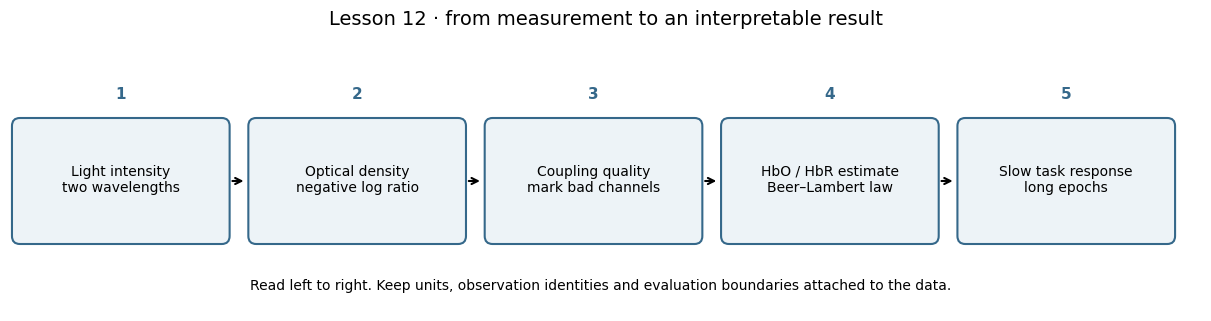

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Light intensity\ntwo wavelengths', 'Optical density\nnegative log ratio', 'Coupling quality\nmark bad channels', 'HbO / HbR estimate\nBeer–Lambert law', 'Slow task response\nlong epochs']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 12 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Light intensity: two wavelengths → Optical density: negative log ratio → Coupling quality: mark bad channels → HbO / HbR estimate: Beer–Lambert law → Slow task response: long epochs.

## Symbols and a calculation by hand

$I/I_0$: relative light intensity; $\Delta OD$: optical-density change; $E$: extinction matrix; $L$: effective pathlength.

### Derive the operation before calling the library

Optical density is $\Delta OD=-\ln(I/I_0)$. Half the reference intensity gives $-\ln0.5=\ln2\approx0.693$; equal intensity gives zero. This logarithm requires positive intensity values.

The simplified two-wavelength system is $\Delta OD=LE\Delta c$. With $E=[[2,1],[1,3]]$, $L=1$ and $\Delta c=[0.4,-0.2]^T$, the observation is $[0.6,-0.2]^T$. Solving recovers the concentration vector. Assuming $L=2$ instead halves the estimate. These coefficients are an algebra example, not biological extinction constants; the real MNE conversion uses wavelength metadata.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### A different measurement of brain-related activity

Functional near-infrared spectroscopy measures light attenuation through tissue at multiple wavelengths. Changes in oxygenated and deoxygenated hemoglobin contribute to the measured intensity. The resulting hemodynamic response is indirect and slower than scalp electrical activity. A response after a motor task can therefore peak seconds after the task begins rather than hundreds of milliseconds after a flash.

The dataset here contains executed finger tapping, not imagined movement. This provides a concrete motor-response demonstration but cannot establish performance for an imagery BCI. Keep the task label visible in plots and reports.

### First transformation: intensity to optical density

Optical density expresses a relative change in intensity:

$$\Delta OD_\lambda(t)=-\ln\frac{I_\lambda(t)}{I_{\lambda,0}}.$$

If intensity decreases relative to the reference, optical density increases. Multiplying both intensity and its reference by the same positive scale does not change this ratio. This is useful, but it does not fix poor optode contact, saturated channels or motion-induced jumps. Inspect raw intensity before conversion and do not take logarithms of invalid nonpositive values.

### Second transformation: wavelength changes to chromophores

In a simplified two-wavelength model,

$$\begin{bmatrix}\Delta OD_{\lambda_1}\\\Delta OD_{\lambda_2}\end{bmatrix}=L\begin{bmatrix}\epsilon_{1,O}&\epsilon_{1,R}\\\epsilon_{2,O}&\epsilon_{2,R}\end{bmatrix}\begin{bmatrix}\Delta[HbO]\\\Delta[HbR]\end{bmatrix}.$$

The extinction coefficients describe wavelength-dependent absorption; the effective path length includes source-detector distance and a pathlength factor. Solving the linear system estimates relative concentration changes. The assumptions include approximate linearity and specified optical parameters. The result is not an absolute measurement of oxygenation at an anatomical point.

MNE performs this conversion with wavelength and optode metadata. The lesson states its pathlength factor explicitly. Changing that factor changes concentration scaling, so amplitudes from different parameter conventions are not directly comparable. The small numerical example below uses arbitrary coefficients only to teach the linear algebra; it is not a physical calibration table.

### Quality control and slow physiology

Scalp coupling index uses physiological consistency across wavelengths as a quality indicator. It supports a channel decision but is not proof that a task effect originates in cortex. Systemic blood flow, superficial tissue and motion can contribute. Short-separation measurements, when available, can help model superficial contributions; this lesson does not invent such channels when the recording does not provide them.

A low-pass filter retains the slow hemodynamic response, while a high-pass filter can reduce very slow drift. Filter choices must respect task duration and baseline length. Aggressive filtering may attenuate the very response of interest. Epochs need a longer post-event interval than P300 analysis, and adjacent task blocks may have overlapping hemodynamic responses.

Sensor-level HbO/HbR averages are the endpoint here. No optical tomography or EEG source imaging is included. A future fNIRS BCI would additionally require trial-level features, a training-only model and evaluation on independent runs or sessions.

## Visual intuition · Follow light attenuation through the logarithm

**Independent exercise:** Predict the sign of optical-density change when intensity is below its reference.

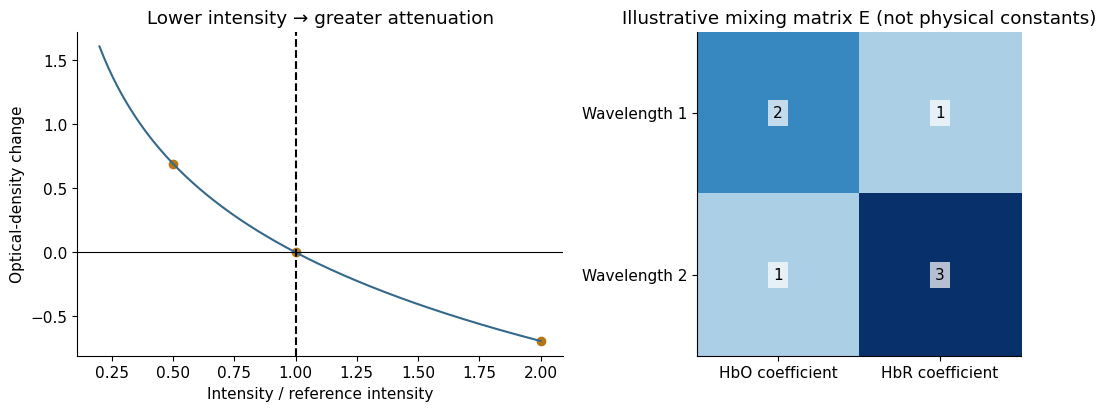

In [3]:
vis_ratio=np.linspace(.2,2,200)
fig,axes=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
axes[0].plot(vis_ratio,-np.log(vis_ratio),color='#35688a')
axes[0].axhline(0,color='black',lw=.8);axes[0].axvline(1,color='black',ls='--')
axes[0].scatter([.5,1,2],-np.log([.5,1,2]),color='#b87714')
axes[0].set(xlabel='Intensity / reference intensity',ylabel='Optical-density change',title='Lower intensity → greater attenuation')
vis_E=np.array([[2,1],[1,3]])
axes[1].imshow(vis_E,cmap='Blues',vmin=0,vmax=3)
for i in range(2):
    for j in range(2):axes[1].text(j,i,str(vis_E[i,j]),ha='center',va='center',color='black',bbox=dict(facecolor='white',alpha=.7,edgecolor='none'))
axes[1].set(xticks=[0,1],xticklabels=['HbO coefficient','HbR coefficient'],yticks=[0,1],yticklabels=['Wavelength 1','Wavelength 2'],title='Illustrative mixing matrix E (not physical constants)')
plt.show()

### Worked interpretation

The logarithm turns an intensity ratio into an additive attenuation change. Two wavelength equations can separate two chromophore changes only under the stated model and optical assumptions; bad coupling and motion remain measurement problems.

## Guided practice 1 · intensity ratios

Convert three intensity ratios to optical density and predict the sign.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_ratio=np.array([.8,1.,1.2])
print(pd.DataFrame({'Intensity ratio':demo_ratio,'Delta optical density':-np.log(demo_ratio)}))

   Intensity ratio  Delta optical density
0              0.8               0.223144
1              1.0              -0.000000
2              1.2              -0.182322


### Why this result makes sense

A reduction in transmitted intensity corresponds to positive optical density change. Units and sign must be tracked across transformations.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · recover two concentrations

Solve a known two-component mixture using arbitrary coefficients.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
demo_E=np.array([[2.,1.],[1.,3.]])
demo_concentration=np.array([.4,-.2])
demo_od=demo_E@demo_concentration
demo_recovered=np.linalg.solve(demo_E,demo_od)
print('Recovered:',demo_recovered)
assert np.allclose(demo_recovered,demo_concentration)

Recovered: [ 0.4 -0.2]


### Why this result makes sense

Two independent wavelength equations can separate two chromophore changes in this simplified model. Nearly dependent equations would make the estimate unstable.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · pathlength scaling

Solve the same optical-density observation using two assumed path lengths.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
for assumed_length in [1.,2.]:
    print('Length:',assumed_length,'Estimated change:',np.linalg.solve(assumed_length*demo_E,demo_od))

Length: 1.0 Estimated change: [ 0.4 -0.2]
Length: 2.0 Estimated change: [ 0.2 -0.1]


### Why this result makes sense

Doubling the assumed effective path length halves the estimated concentration change. Report the convention with any amplitude claim.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · response timescale

Compare sample counts for a 0.8 s electrical-response interval and a 20 s hemodynamic interval at their respective illustrative sampling rates.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
print('EEG example:',round(.8*128),'samples')
print('fNIRS example:',round(20*10),'samples')
print('Observation durations:',.8,'s versus',20,'s')

EEG example: 102 samples
fNIRS example: 200 samples
Observation durations: 0.8 s versus 20 s


### Why this result makes sense

Similar array lengths can represent very different physiological timescales. Interpret duration using the sampling rate, not the number of columns.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Optical-density function

Implement optical_density_change for strictly positive intensity and reference values.

**Independent exercise:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def optical_density_change(intensity, reference):
    # TODO: natural logarithm of the relative intensity.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def optical_density_change(intensity,reference):
    return -np.log(np.asarray(intensity)/reference)

In [10]:
answer=optical_density_change(np.array([.5,1.,2.]),1.)
if answer is not None:
    assert np.allclose(answer,[np.log(2),0,-np.log(2)]); print('Optical-density checks passed.')
else: print('Exercise pending: implement optical_density_change.')

Optical-density checks passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

fNIRS measures changes in detected near-infrared light related to absorption by oxygenated and deoxygenated hemoglobin. It does not measure neuronal voltage. Optical density is $\Delta OD_\lambda=-\ln[I_\lambda(t)/I_{\lambda,0}]$. The modified Beer–Lambert model is $\Delta OD_\lambda=\sum_j\epsilon_{\lambda j}\Delta c_j\,d\,DPF_\lambda$. With multiple wavelengths, solve this linear system for relative HbO/HbR concentration changes.

Source–detector distance and differential pathlength assumptions affect the estimate. Scalp blood flow, motion and systemic physiology can dominate. A low-frequency bandpass does not guarantee removal of superficial signals; short-separation regression is a separate technique. The hemodynamic response develops over seconds, so EEG timing and filtering choices cannot simply be reused.

This native MNE recording contains executed finger tapping and a control condition. It is not a motor-imagery BCI benchmark. The lesson supports the syllabus’s broader physiological-signal objective while keeping that distinction explicit.

## Load and convert intensity
Use documented annotation labels and retain source geometry. PPF is an explicit teaching assumption.

Inspect optical channels and source-detector distances before converting intensity to optical density. Coupling measures flag questionable channels, and Beer–Lambert conversion uses the recorded wavelengths and an explicit pathlength factor.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Store this intermediate result so the next operation can be traced and inspected.

**3.** Read optical intensity and wavelength/optode metadata together.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**6.** Read optode separation distances; this is sensor geometry, not source imaging.

**7.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

In [11]:
# Import the named tools used in this step.
from mne.preprocessing.nirs import optical_density, beer_lambert_law, scalp_coupling_index, source_detector_distances
# Store this intermediate result so the next operation can be traced and inspected.
path = mne.datasets.fnirs_motor.data_path(path=DATA_ROOT, update_path=False)
# Read optical intensity and wavelength/optode metadata together.
intensity = mne.io.read_raw_nirx(path / 'Participant-1', preload=True, verbose=False)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
intensity.annotations.rename({'1.0': 'Control', '2.0': 'Left', '3.0': 'Right'})
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
intensity.annotations.delete(np.where(intensity.annotations.description == '15.0')[0])
# Read optode separation distances; this is sensor geometry, not source imaging.
distance = source_detector_distances(intensity.info)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
intensity.pick(np.where(distance > 0.01)[0])

<RawNIRX | Participant-1, 40 x 23239 (2974.6 s), ~7.1 MiB, data loaded>

### Step 1.2 · trace the next operation

**1.** Convert positive intensity into relative logarithmic attenuation.

**2.** Calculate a quality indicator before interpreting hemoglobin changes.

**3.** Store this intermediate result so the next operation can be traced and inspected.

**4.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**5.** Convert wavelength attenuation to relative HbO/HbR using the declared pathlength factor.

**6.** Apply the declared frequency filter; copy first when the original must be preserved.

In [12]:
# Convert positive intensity into relative logarithmic attenuation.
od = optical_density(intensity)
# Calculate a quality indicator before interpreting hemoglobin changes.
sci = scalp_coupling_index(od)
# Store this intermediate result so the next operation can be traced and inspected.
od.info['bads'] = [ch for ch, s in zip(od.ch_names, sci) if s < 0.5]
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Low-coupling channels:', od.info['bads'])
# Convert wavelength attenuation to relative HbO/HbR using the declared pathlength factor.
haemo = beer_lambert_law(od, ppf=0.1)
# Apply the declared frequency filter; copy first when the original must be preserved.
haemo.filter(0.05, 0.7, h_trans_bandwidth=0.2, l_trans_bandwidth=0.02)

Low-coupling channels: []


<RawNIRX | Participant-1, 40 x 23239 (2974.6 s), ~7.1 MiB, data loaded>

### Inspect and interpret

Track which channels are retained at each step. State the measurement type before and after conversion, and avoid comparing concentration amplitudes across unspecified pathlength conventions.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Inspect the coupling decision

**Independent exercise:** Display channels with the lowest scalp coupling scores and count those marked bad.

**My reasoning / hand calculation:** _write here._

In [13]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

The score is a quality indicator; the threshold is a declared choice.

### Worked solution

Run the following calculation after attempting your own version.

In [14]:
lab_quality=pd.DataFrame({'channel':od.ch_names,'coupling':sci,'marked_bad':[ch in od.info['bads'] for ch in od.ch_names]})
print(lab_quality.sort_values('coupling').head(8))
print('Marked bad:',lab_quality.marked_bad.sum(),'of',len(lab_quality))

      channel  coupling  marked_bad
20  S5_D5 760  0.612043       False
21  S5_D5 850  0.612043       False
0   S1_D1 760  0.644514       False
1   S1_D1 850  0.644514       False
24  S5_D7 760  0.676549       False
25  S5_D7 850  0.676549       False
12  S3_D2 760  0.678239       False
13  S3_D2 850  0.678239       False
Marked bad: 0 of 40


### Interpret and check

The table makes exclusions auditable. A retained channel is not thereby proven to contain only cortical physiology. Coupling, motion, systemic circulation and superficial tissue require separate reasoning.

## Practice 3 · Predict pathlength sensitivity by hand

**Independent exercise:** If the assumed pathlength factor doubles with the same measured optical-density changes, what happens to inferred concentration amplitudes?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Solve Δc = (LE)⁻¹ ΔOD with L replaced by 2L.

### Worked solution

They halve in the simplified linear model while the temporal shape remains the same. This is why pathlength conventions must accompany amplitude comparisons. Changing an optical assumption is not evidence that physiology changed.

## Epoch the slow response
Use a long post-event interval and report how channel-quality choices affect interpretation.

Long epochs capture a slow motor-related hemodynamic response. The plotted average is across retained HbO channels, which is a descriptive summary that may hide spatial heterogeneity.

### Step 2.1 · trace the next operation

**1.** Translate documented annotation descriptions into discrete event codes.

**2.** Create event-aligned trials with the stated interval, baseline and quality rules.

In [15]:
# Translate documented annotation descriptions into discrete event codes.
events, event_id = mne.events_from_annotations(haemo, event_id={'Control': 1, 'Left': 2, 'Right': 3})
# Create event-aligned trials with the stated interval, baseline and quality rules.
epochs = mne.Epochs(haemo, events, event_id, -5, 15, baseline=(-5, 0), preload=True)

### Step 2.2 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Plot each named condition on comparable axes without changing its observations.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Render the completed figure and inspect labels, units and the comparison.

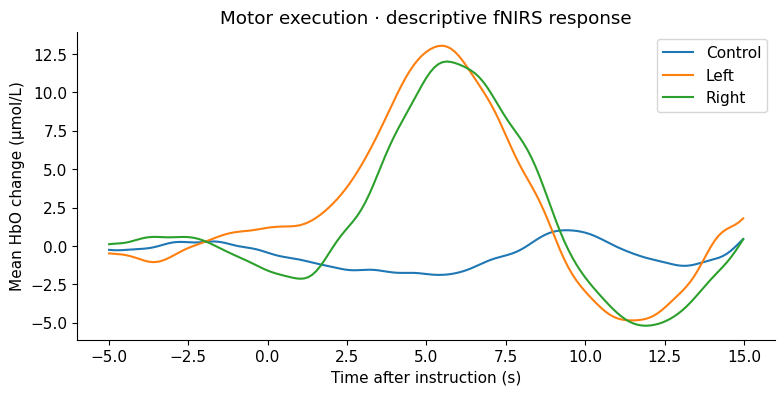

In [16]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Plot each named condition on comparable axes without changing its observations.
for name in ['Control', 'Left', 'Right']:
    ev = epochs[name].average(picks='hbo')
    ax.plot(ev.times, ev.data.mean(0) * 1000000.0, label=name)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlabel='Time after instruction (s)', ylabel='Mean HbO change (µmol/L)', title='Motor execution · descriptive fNIRS response')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.legend()
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Compare task timing with response timing. Inspect HbR separately in the exercise, and explain why executed tapping is not evidence for imagery decoding.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 4 · Compare HbO and HbR with their units intact

**Independent exercise:** Plot mean HbO and HbR for the left-tapping condition. Avoid forcing them to have opposite signs.

**My reasoning / hand calculation:** _write here._

In [17]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Select channel types separately and use the same time axis.

### Worked solution

Run the following calculation after attempting your own version.

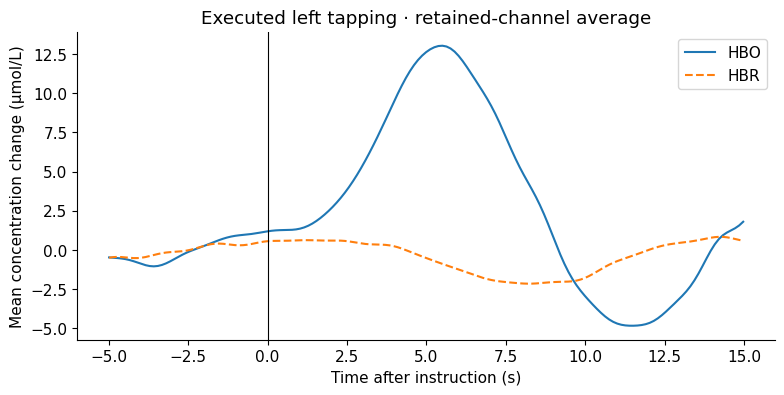

In [18]:
fig,ax=plt.subplots(figsize=(9,4))
for kind,style in [('hbo','-'),('hbr','--')]:
    lab_ev=epochs['Left'].average(picks=kind)
    ax.plot(lab_ev.times,lab_ev.data.mean(axis=0)*1e6,style,label=kind.upper())
ax.axvline(0,color='black',lw=.8)
ax.set(xlabel='Time after instruction (s)',ylabel='Mean concentration change (µmol/L)',title='Executed left tapping · retained-channel average')
ax.legend();plt.show()

### Interpret and check

The traces are measured estimates under the stated pathlength convention. They need not mirror one another perfectly because physiology, noise and the averaging of heterogeneous channels all contribute. This is executed tapping, not imagery decoding.

## Practice 5 · Design a slow-response decision

**Independent exercise:** Why would an fNIRS interface generally need a different decision window from a P300 detector?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Compare hemodynamic and electrical response timescales.

### Worked solution

Hemodynamic changes unfold over seconds and may overlap between task blocks. A short P300-style window can miss much of that response. A proposed fNIRS decoder needs a suitable baseline, long enough evidence interval, grouped evaluation and explicit latency accounting.

## Recorded-signal inspection with MNE-Python

The following visualization uses the recording analysed in this notebook. The API retains channel names, sample timing and physical units. This is descriptive inspection; it does not authorize selecting parameters on held-out labels.

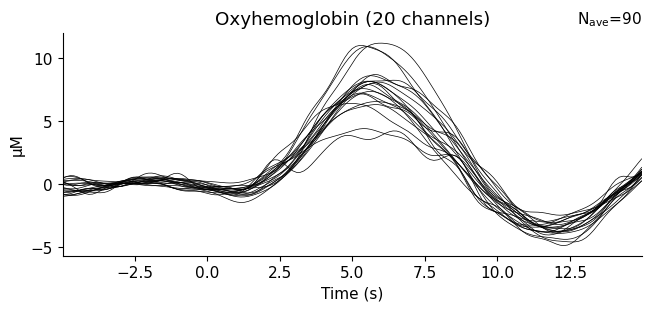

In [19]:
# Average recorded haemoglobin epochs and use the native MNE evoked display.
recorded_evoked = epochs.average(picks='hbo')
recorded_evoked.plot(spatial_colors=False, show=False)
plt.show()

### Figure interpretation and independent exercise

This panel displays haemodynamic concentration changes rather than EEG. Read the concentration and time units from the axes. Channel differences can reflect task response, contact quality or systemic physiology. They do not alone establish an independently validated BCI.

**Exercise.** Identify the measurement unit, the observation represented by each trace or image row, and one conclusion that the figure cannot support. Explain how the answer changes if the signal has already been filtered.

**Reference interpretation.** The displayed observations are processed sensor measurements, not independent participants. Filtering changes the measured bandwidth and temporal structure. The plot supports quality assessment and descriptive comparisons; it does not establish causal neural mechanisms, source location or out-of-sample classification performance.

The display pools the retained conditions and is intended to demonstrate measurement scale and between-channel variation. Use the condition-specific analyses above for tapping-versus-control comparisons.

## Practice 6 · explain the complete method

Independently explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

Intensity becomes optical density through a logarithmic ratio, then relative hemoglobin changes through an assumed optical model. Quality, systemic physiology and pathlength conventions matter. Slow executed-tapping responses do not establish an imagery BCI.

## If your result is different

If logarithms are invalid, inspect raw positive intensity and saturation. If conversion amplitudes differ, check wavelength metadata, units, distances and pathlength conventions.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[MNE fNIRS processing](https://mne.tools/stable/auto_tutorials/preprocessing/70_fnirs_processing.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.

## References and further reading

1. [Gramfort et al. (2013), MEG and EEG data analysis with MNE-Python](https://doi.org/10.3389/fnins.2013.00267). Core data structures and reproducible electrophysiological analysis.
2. [MNE motor fNIRS acquisition and analysis tutorial](https://mne.tools/stable/auto_tutorials/preprocessing/70_fnirs_processing.html). Acquisition provenance, task definition and dataset-specific interpretation.
3. [MNE-Python API reference](https://mne.tools/stable/python_reference.html). Consult the documented units, defaults and return values of each method.
4. [MNE overview tutorial](https://mne.tools/stable/auto_tutorials/intro/10_overview.html). Relationship between continuous data, epochs and evoked responses.
5. [MNE documentation on in-place modification](https://mne.tools/stable/auto_tutorials/intro/15_inplace.html). Object copying and preservation of analysis branches.

These references support the acquisition and software descriptions. Numerical outcomes in this notebook refer only to the explicitly selected data and evaluation design; they are not population performance estimates. Dataset terms remain separate from the licence of these teaching materials.
